# 07 · PJM Energy Demand — Univariate Forecasting (naive, harmonic, MSTL-AutoARIMA)

## Part 7 — Univariate Forecasting

Now we *forecast*. The operational question for a grid is **day-ahead demand**; to stress the models we
forecast a **14-day horizon** from a fixed origin (the last fortnight of the data) using only the
series' own history. Four approaches of rising sophistication:

1. **Seasonal-naive** — repeat yesterday / last week (the bar to beat),
2. **Harmonic (Fourier) regression** — deterministic daily+weekly+annual cycles,
3. **MSTL + AutoARIMA** — decompose the multiple seasonalities and model the remainder.

The comparison teaches *why* pure calendar models are not enough, and how much the autocorrelated
remainder is worth. (Part 9 does proper rolling day-ahead backtesting; this is the model bake-off.)

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import forecasting as F
from sklearn.linear_model import LinearRegression
d = data.clean_primary(); s = d.load_mw
H = 24*14; train, test = s.iloc[:-H], s.iloc[-H:]
print("train %d hours (-> %s) | test %d hours (%s -> %s)" % (len(train), train.index[-1].date(), H, test.index[0].date(), test.index[-1].date()))

setup ok | numpy 2.1.3 | pandas 2.3.3


train 145056 hours (-> 2018-07-20) | test 336 hours (2018-07-20 -> 2018-08-03)


### 1. Seasonal-naive baselines

The honest bar: forecast each hour as the **same hour yesterday** (lag 24) or **last week** (lag 168).
For load, "same hour yesterday" is a genuinely strong baseline — any model that can't beat it adds
nothing.

In [2]:
results = {}
for m, nm in [(24, "snaive-24h"), (168, "snaive-168h")]:
    results[nm] = F.seasonal_naive(train, H, m)
print(pd.DataFrame({nm: F.metrics(test.values, yp, train, nm) for nm, yp in results.items()}).T.to_string())

                  MAE      RMSE   MAPE%   WAPE%   MASE
snaive-24h   3110.390  3882.505   8.779   8.747  1.432
snaive-168h  3699.449  4982.471  10.534  10.404  1.704


### 2. Harmonic (Fourier) regression

Represent the three cycles as smooth sine/cosine waves and fit a linear trend + harmonics. This
captures the *deterministic* seasonal shape beautifully — but it has **no memory of recent demand**, so
when a heat wave lifts the whole week above the seasonal norm, it can't follow. Expect a good *shape*,
a wrong *level*.

In [3]:
Xtr = F.fourier_features(train.index); Xte = F.fourier_features(test.index)
Xtr["t"] = (train.index - train.index[0]) / pd.Timedelta(hours=1)
Xte["t"] = (test.index - train.index[0]) / pd.Timedelta(hours=1)
lr = LinearRegression().fit(Xtr, train.values)
results["harmonic-OLS"] = lr.predict(Xte)
print(F.metrics(test.values, results["harmonic-OLS"], train, "harmonic-OLS").to_string())

MAE      4268.278
RMSE     5289.361
MAPE%      11.722
WAPE%      12.003
MASE        1.966

### 3. MSTL + AutoARIMA

The proper multi-seasonal model: **MSTL** strips out the daily (24) and weekly (168) seasonals, an
**AutoARIMA** forecasts the deseasonalised remainder (capturing the recent level the harmonic model
missed), and the seasonals are added back. This is the state of the art for classical load forecasting
— and the only model here that **beats the seasonal-naive baseline**. (Fitting takes a couple of
minutes.)

In [4]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA
sdf = pd.DataFrame({"unique_id": "pjme", "ds": train.index, "y": train.values})
sf = StatsForecast(models=[MSTL(season_length=[24, 168], trend_forecaster=AutoARIMA())], freq="h", n_jobs=1)
sf.fit(sdf); fc = sf.predict(h=H)
results["MSTL-AutoARIMA"] = fc["MSTL"].values
print(F.metrics(test.values, results["MSTL-AutoARIMA"], train, "MSTL-AutoARIMA").to_string())

MAE      2556.055
RMSE     3244.447
MAPE%       7.242
WAPE%       7.188
MASE        1.177


### 4. The bake-off

All four on one scoreboard and one chart. **MSTL+AutoARIMA wins** (MAPE ~7%, beating seasonal-naive by
~18%); the **harmonic model is worst** — vivid proof that for load you need *both* the seasonal shape
*and* a model of recent deviations. The chart shows harmonic tracking the rhythm but sitting at the
wrong level, while MSTL hugs the actual.

                     MAE      RMSE   MAPE%   WAPE%   MASE
snaive-24h      3110.390  3882.505   8.779   8.747  1.432
snaive-168h     3699.449  4982.471  10.534  10.404  1.704
harmonic-OLS    4268.278  5289.361  11.722  12.003  1.966
MSTL-AutoARIMA  2556.055  3244.447   7.242   7.188  1.177


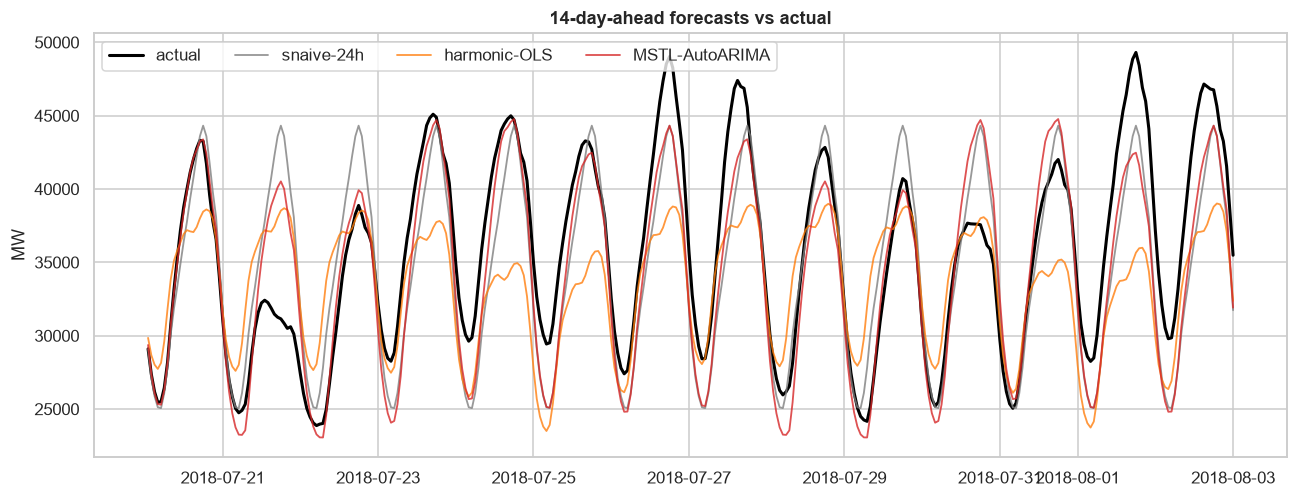


best: MSTL-AutoARIMA (MAPE 7.2%, 18% better than snaive-24h)


In [5]:
board = pd.DataFrame({nm: F.metrics(test.values, yp, train, nm) for nm, yp in results.items()}).T
print(board.to_string())
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test.values, color="black", lw=2, label="actual")
for nm, c in [("snaive-24h","tab:gray"), ("harmonic-OLS","tab:orange"), ("MSTL-AutoARIMA","tab:red")]:
    ax.plot(test.index, results[nm], lw=1.2, alpha=.8, label=nm, color=c)
ax.set_ylabel("MW"); ax.set_title("14-day-ahead forecasts vs actual"); ax.legend(ncol=4)
eda.savefig(fig, "p7_forecasts.png"); plt.show()
print("\nbest: %s (MAPE %.1f%%, %.0f%% better than snaive-24h)" %
      (board.MAE.idxmin(), board.loc[board.MAE.idxmin(),"MAPE%"], 100*(1-board.MAE.min()/board.loc["snaive-24h","MAE"])))

### Takeaways

- **Seasonal-naive (same hour yesterday)** is a strong baseline (~8.8% MAPE) — the bar.
- **Harmonic regression** nails the *shape* but misses the *level* (no memory) → worst MAPE; pure
  deterministic seasonality is not enough for weather-driven load.
- **MSTL + AutoARIMA** is the classical winner (~7.2% MAPE, ~18% better than naive) — decompose the
  seasonalities, model the remainder.
- The gap between harmonic and MSTL = the value of modelling the **autocorrelated remainder** (recent
  weather).

**Next — Part 8 (ML forecasting):** give a gradient-boosted model **lag features + calendar + Fourier
terms** and see it exploit the persistence (Part 2) to push day-ahead accuracy further.